In [2]:
import pandas as pd
import numpy as np  
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import f1_score


train = pd.read_csv('train.csv')    
test = pd.read_csv('test.csv')  
submission = pd.read_csv('sample_submission.csv')

* ### EDA
Om de data goed te kunnen gebruiken moet het voldoen aan wat voorwaarden zodat we het kunnen verwerken met Scikit Learn. In de onderstaande code word gekeken of er aan deze voorwaarden voldaan wordt. Zo wordt er gekeken naar of er ontbrekende of dubbele waarden zijn, of het numerieke waarden zijn en wat de form van de dataset is.

In [3]:
def VoldoetDf(df, naam):

    print(f"Analyse van DataFrame: {naam}")

    # Controleren op missende waarden
    missende_waarden = df.isnull().sum()
    if sum(missende_waarden) > 0:
            print(f'Er zijn {sum(missende_waarden)} missende waarden')
    else:
        print('Er zijn geen missende waarden')

    # Controleren op dubbele rijen
    dubbele_rijen = df.duplicated().sum()
    if dubbele_rijen > 0:
        print(f'Er zijn {dubbele_rijen} dubbele rijen')
    else:
        print('Er zijn geen dubbele rijen')

    # Controleer de datatypes van de kolommen
    data_types = df.dtypes
    print("Data types:", data_types.unique())

    # Controleer de vorm van de DataFrame
    print(f'De DataFrame heeft {df.shape[0]} rijen en {df.shape[1]} kolommen')

    # Witregel voor betere leesbaarheid
    print()
    
VoldoetDf(train, 'train')
VoldoetDf(test, 'test')
VoldoetDf(submission, 'submission')


Analyse van DataFrame: train
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64') dtype('float64') dtype('bool')]
De DataFrame heeft 33550 rijen en 22 kolommen

Analyse van DataFrame: test
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64') dtype('float64') dtype('bool')]
De DataFrame heeft 8388 rijen en 21 kolommen

Analyse van DataFrame: submission
Er zijn geen missende waarden
Er zijn geen dubbele rijen
Data types: [dtype('int64')]
De DataFrame heeft 8388 rijen en 2 kolommen



De data voldoet aan alle eisen van Scikit Learn. Er zijn namelijk geen missende waarden, alle data is numeriek (of een boolean) en de testset en de datasets zijn tweedimensionaal. De testset en de submission set is ook even groot en zou dus geen problemen moeten opleveren.

Toon de datatypes en basisstatistieken van iedere kolom.

In [4]:
display(train.describe(), train.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33550 entries, 0 to 33549
Data columns (total 22 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   id                              33550 non-null  int64  
 1   age                             33550 non-null  float64
 2   hypertension                    33550 non-null  int64  
 3   heart_disease                   33550 non-null  int64  
 4   avg_glucose_level               33550 non-null  float64
 5   bmi                             33550 non-null  float64
 6   gender_Female                   33550 non-null  bool   
 7   gender_Male                     33550 non-null  bool   
 8   gender_Other                    33550 non-null  bool   
 9   ever_married_No                 33550 non-null  bool   
 10  ever_married_Yes                33550 non-null  bool   
 11  work_type_Govt_job              33550 non-null  bool   
 12  work_type_Never_worked          

,id,age,hypertension,heart_disease,avg_glucose_level,bmi,stroke
count,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000,33550.000000
mean,36746.393353,41.815312,0.088137,0.043040,103.587081,28.601216,0.015410
std,20906.519131,22.477423,0.283498,0.202951,42.127396,7.782248,0.123178
min,1.000000,0.080000,0.000000,0.000000,55.010000,10.100000,0.000000
25%,18763.250000,24.000000,0.000000,0.000000,77.460000,23.300000,0.000000
50%,36862.000000,43.000000,0.000000,0.000000,91.320000,27.700000,0.000000
75%,54757.500000,59.000000,0.000000,0.000000,111.437500,32.800000,0.000000
max,72943.000000,82.000000,1.000000,1.000000,281.590000,97.600000,1.000000


None

We onderzoeken de relatie tussen onze features onderling en de relatie met onze target. Hiermee kunnen we voorkomen dat er multicollineariteit optreed in ons model. In de onderstaande cel kijken we welke features een hoge correlatie met elkaar hebben.

In [5]:
corr_matrix = train.corr(numeric_only=True)

# Filter paren met een absolute correlatie groter dan 0.3 (exclusief de diagonaal van 1.0)
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # Voorkomt dubbele paren en de correlatie van een kolom met zichzelf
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.5:
                print(f"{col1} - {col2}: {corr_val:.2f}")


age - ever_married_No: -0.69
age - ever_married_Yes: 0.69
age - work_type_children: -0.64
gender_Female - gender_Male: -1.00
ever_married_No - ever_married_Yes: -1.00
ever_married_No - work_type_children: 0.55
ever_married_Yes - work_type_children: -0.55
Residence_type_Rural - Residence_type_Urban: -1.00


We zien dat sommige features een perfecte correlatie hebben en dat is heel logisch. De features zijn dummy kolommen en zijn uit de kolom voortgekomen. Om dit op te lossen kunnen we simpelweg 1 van de dummy kolommen verwijderen.

In [5]:
drop_columns = ['gender_Female', 'ever_married_No', 'Residence_type_Rural', 'smoking_status_never smoked', 'work_type_Private']
train = train.drop(columns=drop_columns)

Als we nu kijken welke features nog een hoge correlatie hebben zien we dat het er een stuk minder zijn.

In [6]:
corr_matrix = train.corr(numeric_only=True)

# Filter paren met een absolute correlatie groter dan 0.3 (exclusief de diagonaal van 1.0)
for col1 in corr_matrix.columns:
    for col2 in corr_matrix.columns:
        if col1 < col2:  # Voorkomt dubbele paren en de correlatie van een kolom met zichzelf
            corr_val = corr_matrix.loc[col1, col2]
            if abs(corr_val) > 0.5:
                print(f"{col1} - {col2}: {corr_val:.2f}")

age - ever_married_Yes: 0.69
age - work_type_children: -0.64
ever_married_Yes - work_type_children: -0.55


De correlatie tussen deze features is nog niet hoog genoeg om voor multicollineariteit te zorgen, omdat daar een sterke correlatie van minstens 0.7 voor nodig is.

We zien dat de features geen grote correlatie hebben met de target. Dit betekent dat ons model naar alle features zal moeten gaan kijken om een goede voorspelling te kunnen maken.

### Conclusie EDA:
De data voldoet al aan alle eisen van machine learning met Scikit Learn. Er waren features die te veel met elkaar correleerde, maar dat is opgelost door bepaalde features te verwijderen. Er zijn geen features die veel overeenkomen met onze target dus we zullen naar alle features moeten gaan kijken.

In [8]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from scipy.stats import pointbiserialr, chi2_contingency


target_col = 'stroke'


# ---------------------------------------------------
# 1. Kolommen opdelen
# ---------------------------------------------------

numerical_cols = [
    'age',
    'avg_glucose_level',
    'bmi'
]

categorical_cols = [
    'heart_disease',
    'hypertension',
    'ever_married_Yes',
    'work_type_Self-employed',
    'smoking_status_formerly smoked',
    'gender_Male',
    'smoking_status_smokes',
    'Residence_type_Urban',
    'gender_Other',
    'work_type_Govt_job',
    'work_type_Never_worked',
    'work_type_children'
]


# ---------------------------------------------------
# 2. Functie voor Cramér's V
# ---------------------------------------------------

def cramers_v(x, y):
    confusion_matrix = pd.crosstab(x, y)

    chi2 = chi2_contingency(confusion_matrix)[0]
    n = confusion_matrix.sum().sum()

    phi2 = chi2 / n

    r, k = confusion_matrix.shape

    return np.sqrt(phi2 / min(k - 1, r - 1))


# ---------------------------------------------------
# 3. Point-biserial correlatie voor numerieke features
# ---------------------------------------------------

numerical_correlations = {}

for col in numerical_cols:

    # Alleen rijen gebruiken zonder missende waarden
    temp = train[[col, target_col]].dropna()

    corr, p_value = pointbiserialr(
        temp[target_col],
        temp[col]
    )

    numerical_correlations[col] = corr


# ---------------------------------------------------
# 4. Cramér's V voor categorische features
# ---------------------------------------------------

categorical_correlations = {}

for col in categorical_cols:

    temp = train[[col, target_col]].dropna()

    corr = cramers_v(
        temp[col],
        temp[target_col]
    )

    categorical_correlations[col] = corr


# ---------------------------------------------------
# 5. Alles samenvoegen
# ---------------------------------------------------

correlations = {
    **numerical_correlations,
    **categorical_correlations
}

correlations = pd.Series(correlations)

# Sorteren van hoogste naar laagste
correlations = correlations.sort_values(ascending=False)


# ---------------------------------------------------
# 6. Grafiek maken
# ---------------------------------------------------

plt.figure(figsize=(10, 8))

ax = sns.barplot(
    x=correlations.values,
    y=correlations.index,
    hue=correlations.index,
    legend=False,
    palette='coolwarm'
)

# Waarde achter iedere balk zetten
for container in ax.containers:
    ax.bar_label(
        container,
        fmt='%.3f',
        padding=3
    )


plt.title('Samenhang van features met stroke')
plt.xlabel('Correlatie / Cramér\'s V')
plt.ylabel('Features')

plt.axvline(
    0,
    color='black',
    linestyle='--',
    linewidth=0.8
)

plt.grid(
    axis='x',
    linestyle=':',
    alpha=0.6
)

plt.tight_layout()
plt.show()

KeyError: "['gender_Other'] not in index"

In [7]:
train = train.drop(columns=["gender_Other", "id"])

### Conclusie EDA:
De data voldoet al aan alle eisen van machine learning met Scikit Learn. Er waren features die te veel met elkaar correleerde, maar dat is opgelost door bepaalde features te verwijderen. Er zijn geen features die veel overeenkomen met onze target dus we zullen naar alle features moeten gaan kijken. Gender_other heeft een correlatie van 0.000, dus deze kan weggehaald worden.

### Standardiseren
In veel gevallen ligt alle data niet op dezelfde schaal. Bijvoorbeeld in de dataset uit deze opdracht heeft een kolom zoals "heart_disease" een waarde van 0 of 1, maar age kan bijvoorbeeld 70 zijn. Bij de meeste ML modellen zal age dan veel meer invloed hebben op de voorspelling, omdat de waarde zo veel hoger ligt. Maar allebei de features hebben invloed op de voorspelling, dus wat doen we dan? In dit geval zullen wij kunnen standardiseren. Bij standardiseren worden alle features op dezelfde schaal gebracht. Als wij kijken naar de kolommen in de train- en testset, moet standardisatie zeker toegepast worden. Dit word in de code cel hieronder toegepast:

In [9]:
from sklearn.preprocessing import StandardScaler
X_train = train.drop(columns=["stroke"])
y_train = train["stroke"]
# Nieuwe scaler aanmaken
scaler = StandardScaler()

# Alleen numerieke kolommen selecteren
bool_kolommen = X_train.select_dtypes(include="bool").columns
X_train[bool_kolommen] = X_train[bool_kolommen].astype(int)
numerieke_kolommen = X_train.select_dtypes(include="number").columns

# Standardiseren en terugzetten in de dataset
X_train[numerieke_kolommen] = scaler.fit_transform(X_train[numerieke_kolommen])
display(X_train)
display(y_train)

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_smokes
0,-0.525660,-0.310896,-0.212075,-0.949208,0.603791,1.217776,-1.329375,-0.376018,-0.064965,-0.424665,-0.410984,-1.00006,-0.450537,2.398871
1,1.476378,3.216513,-0.212075,2.648741,2.492734,-0.821169,0.752233,-0.376018,-0.064965,2.354796,-0.410984,-1.00006,-0.450537,-0.416863
2,-1.193007,-0.310896,-0.212075,0.750898,-1.233751,1.217776,-1.329375,-0.376018,-0.064965,-0.424665,-0.410984,-1.00006,-0.450537,-0.416863
3,0.230665,-0.310896,-0.212075,-0.918587,-0.051556,1.217776,0.752233,-0.376018,-0.064965,2.354796,-0.410984,0.99994,-0.450537,-0.416863
4,0.319645,-0.310896,-0.212075,2.818942,0.025544,1.217776,0.752233,-0.376018,-0.064965,2.354796,-0.410984,-1.00006,2.219575,-0.416863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33545,-1.459945,-0.310896,-0.212075,0.147481,-1.811999,1.217776,-1.329375,-0.376018,-0.064965,-0.424665,2.433183,-1.00006,-0.450537,-0.416863
33546,0.230665,-0.310896,-0.212075,-0.355524,0.282543,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,-0.416863
33547,-1.726883,-0.310896,-0.212075,-0.330125,-1.593550,-0.821169,-1.329375,-0.376018,-0.064965,-0.424665,2.433183,-1.00006,-0.450537,-0.416863
33548,0.631073,3.216513,-0.212075,-0.501987,-0.102956,-0.821169,0.752233,2.659448,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,2.398871


0        0
1        0
2        0
3        0
4        0
        ..
33545    0
33546    0
33547    0
33548    0
33549    0
Name: stroke, Length: 33550, dtype: int64

# 2
### Metrics
Metrics zijn bepaalde functies die je gebruikt om de prestatie van je model na het trainen, te beoordelen. Dit word gedaan op de testset. In deze dataset moeten wij een klasse voorspellen **(0 is geen stroke, 1 is gelijk aan stroke)**. De metrics die wij kunnen gebruiken zijn:

**Accuracy:** Hoeveel van de voorspellingen zijn juist voorspeld door het model?

**Recall:** Hoeveel van de positieve klassen worden teruggevonden door het model?

**Precision:** Als het model een positieve klasse voorspelt, hoe vaak is dit juist?

**F1-score:** Een combinatie tussen Recall en Precision




### test set klaarmaken:

In [10]:
drop_columns = ['gender_Female', 'ever_married_No', 'Residence_type_Rural', 'smoking_status_never smoked', 'work_type_Private']
test = test.drop(columns=drop_columns)
test = test.drop(columns=["gender_Other", "id"])
X_test = test
y_test = submission.drop(columns=["id"])
bool_kolommen = X_test.select_dtypes(include="bool").columns
X_test[bool_kolommen] = X_test[bool_kolommen].astype(int)
numerieke_kolommen = X_test.select_dtypes(include="number").columns
X_test[numerieke_kolommen] = scaler.transform(X_test[numerieke_kolommen])
display(X_test)
display(y_test)

,age,hypertension,heart_disease,avg_glucose_level,bmi,gender_Male,ever_married_Yes,work_type_Govt_job,work_type_Never_worked,work_type_Self-employed,work_type_children,Residence_type_Urban,smoking_status_formerly smoked,smoking_status_smokes
0,0.453114,-0.310896,-0.212075,-0.148767,-0.873953,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,2.398871
1,-0.525660,-0.310896,-0.212075,2.953061,2.454184,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,2.398871
2,-0.703619,-0.310896,-0.212075,0.230089,-0.539854,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,-0.416863
3,-0.792599,-0.310896,-0.212075,-0.580084,-0.976752,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,2.219575,-0.416863
4,0.942501,-0.310896,-0.212075,-0.329887,0.603791,-0.821169,0.752233,-0.376018,-0.064965,-0.424665,-0.410984,0.99994,-0.450537,-0.416863
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8383,-0.792599,-0.310896,-0.212075,-0.618302,-0.462754,-0.821169,-1.329375,-0.376018,-0.064965,-0.424665,-0.410984,-1.00006,-0.450537,-0.416863
8384,-1.104027,-0.310896,-0.212075,-0.085387,-0.758303,-0.821169,-1.329375,-0.376018,-0.064965,2.354796,-0.410984,-1.00006,-0.450537,-0.416863
8385,-1.370965,-0.310896,-0.212075,-0.557296,-0.822553,-0.821169,-1.329375,-0.376018,-0.064965,-0.424665,2.433183,0.99994,-0.450537,-0.416863
8386,-1.148517,-0.310896,-0.212075,0.039712,2.428484,-0.821169,-1.329375,-0.376018,-0.064965,-0.424665,-0.410984,-1.00006,-0.450537,-0.416863


,stroke
0,1
1,0
2,1
3,0
4,1
...,...
8383,0
8384,0
8385,1
8386,0


### Uitvoeren model:

In [12]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# SVC model
svc_model = SVC(
    kernel="rbf",
    C=1.0,
    gamma="scale",
    class_weight="balanced",  # handig als je binaire klassen ongelijk verdeeld zijn
    random_state=42
)

# Model trainen
svc_model.fit(X_train, y_train)

# Voorspellingen
y_pred = svc_model.predict(X_test)

# Evaluatie
print("Accuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.5021459227467812

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.80      0.62      4241
           1       0.49      0.20      0.28      4147

    accuracy                           0.50      8388
   macro avg       0.50      0.50      0.45      8388
weighted avg       0.50      0.50      0.45      8388


Confusion Matrix:
[[3380  861]
 [3315  832]]


## Confusion Matrix

|                      | Voorspeld positief | Voorspeld negatief |
|----------------------|--------------------:|--------------------:|
| **Werkelijk positief** | TP = True Positive | FN = False Negative |
| **Werkelijk negatief** | FP = False Positive | TN = True Negative |

## Metrics op basis van de Confusion Matrix

| Metric | Formule | Betekenis |
|---|---|---|
| **Accuracy** | $\frac{TP + TN}{TP + TN + FP + FN}$ | Hoeveel % van de voorspellingen zijn juist voorspeld door het model? |
| **Recall** | $\frac{TP}{TP + FN}$ | Hoeveel % van de positieve klassen worden teruggevonden door het model? |
| **Precision** | $\frac{TP}{TP + FP}$ | Van alle positieve voorspelde gevallen: hoeveel % zijn echt positief? |
| **F1-score** | $2 \cdot \frac{Precision \cdot Recall}{Precision + Recall}$ | Een combinatie tussen Recall en Precision |

### Waarom F1-score bij dit vraagstuk?

De beste manier om dit uit te leggen, is omdat het mogelijk is om bij elk andere metric het model te optimaliseren om het heel goed op deze metric, en alleen op deze metric het goed te doen. Bij een Kaggle-wedstrijd zou je in principe bij elke Metric behalve F1-score "vals" kunnen spelen om een perfecte score te krijgen en de wedstrijd te winnen. Maar dan hoef je niet een goed model te ontwikkelen maar alleen op een metric goed te presteren.

**Accuracy:** *Kan niet.* In het geval van een imbalanced dataset zoals deze, zal het model (bijna) altijd negatief kunnen voorspellen en alsnog een bijna perfecte score te krijgen, terwijl het de belangrijkste gevallen niet kan voorspellen.

**Recall:** *Kan niet.* Het model zal (bijna) altijd positief kunnen voorspellen en dan zal het model alle strokes terug kunnen vinden. De metric is dan perfect, maar het model is waardeloos.

**Precision:** *Kan niet.* Het model zal (bijna) altijd negatief kunnen voorspellen maar alleen bij *HELE zekere* gevallen positief kunnen voorspellen. Dan zijn alle positieve voorspellingen juist, maar het model zal dan bijna nooit een voorspelling maken tenzij het heel zeker is.

**F1-Score:** *Kan wel.* Het is een combinatie tussen Precision en Recall. Om een perfecte score te krijgen voor Recall moet je altijd positief voorspellen, bij precision moet je juist bijna nooit positief voorspellen. Dit betekent dat om voor allebei deze metrics tegelijkertijd een perfecte score te krijgen, onmogelijk is. De formule voor de F1-score is ook zo opgesteld dat een hele lage score voor één van de twee metrics de F1-score sterk naar beneden trekt. Als je het model bijvoorbeeld optimaliseert voor de Recall door alleen positief te voorspellen (score van 1 voor de recall), maar de Precision is bijna 0 is, dan zal de F1-score alsnog bijna 0 zijn, dan maakt het niet uit hoe hoog de Recall is zo lang de Precision laag is. 

*De F1-score is de enige metric waarbij niet vals gespeeld kan worden om je model er "perfect" uit te laten zien.*


## 3 - modellen

SVM:
- Beschrijf de werking van dit model. Toon hierbij de relevante wiskundige
formules en leg ze uit aan de hand van een rekenvoorbeeld. Gebruik hierbij
een klein deel van de dataset. Leg ook uit wat een kernel is en wat de kernel
trick is.
- Toon de wiskundig formule voor de loss functie en ligt deze toe.
- Benoem de vormen van regularisatie die van toepassing zijn op dit model.
Leg aan de hand van wiskundige formules uit hoe iedere vorm werkt en wat
het effect is van iedere vorm.
- Bepaal bij welke hyperparameters het model de beste resultaten geeft op de
gekozen metric.

#### SVM:
Een SVM (of een Support Vector Machine) is een lineair model dat ook werkt op data die uit zichzelf niet lineair is. Dit kan het model verwerken door aan de hand van een wiskundige formule een extra as/dimensie te introduceren. De gebruiker van het model kiest wat voor soort functie er gebruikt moet worden. Die functie heet ook wel een kernel. 

Standaard kernel is de RBF kernel, de functie hiervan is: 
\begin{align}K(\mathbf{x}_1, \mathbf{x}_2) = \exp\left(-\gamma \cdot
      {\|\mathbf{x}_1 - \mathbf{x}_2\|^2}\right)\end{align} 
Om de beste scheiding te kunnen maken tussen de punten kan de kernel trick worden toegepast. Hierbij wordt de afstand tussen de punten in de hogere dimensie berekend, zonder de punten zelf echt te transformeren. De functie hiervoor is:
$$k(x, x') = f(x) \cdot f(x')$$

Vervolgens scheidt het model de punten aan de hand van een lineair hypervlak. Een hypervlak is een lineare lijn in een meerdimensionale ruimte. Hierdoor zal het in een 2d weergave vaak ook te zien zijn als een lijn, alleen is de lijn dan niet meer lineair.

##### Loss:
Om de loss van een SVM uit te rekenen maken we gebruik van hinge loss. Een SVM stelt een margin in om te bepalen of een punt dicht genoeg bij de beslissingsgrens ligt om potentieel verkeerd voorspeld te worden, waarna hinge loss berekent hoeveel straf het model daarvoor krijgt. De punten die al diep in eigen gebied liggen worden niet gebruikt om de beslissingsgrens op te stellen, maar de punten die op de rand of binnen de margin vallen bepalen precies hoe de beslissingsgrens loopt. Deze punten heten de support vectors.

Hinge loss heet zo omdat de grafiek van de hoeveel punten gestraft worden aan de hand van waar ze liggen, een scharnier (hinge) lijkt te hebben. Dit komt omdat het zodra een punt buiten de margin valt er niet meer naar kijkt en het een score van nul geeft. Hierdoor ontstaat er ineens een rechte lijn.

De formule voor hinge loss is:
$$L(y, f(x)) = \max(0, 1 - y \cdot f(x))$$

In [13]:
import pandas as pd
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Data voorbereiden (zonder StandardScaler!)
X_full = train.drop(columns=["stroke"]).copy()
y_full = train["stroke"].copy()

bool_cols_full = X_full.select_dtypes(include="bool").columns
X_full[bool_cols_full] = X_full[bool_cols_full].astype(int)

X_test = test.copy()
if "id" in X_test.columns:
    test_ids = X_test["id"].copy()
    X_test = X_test.drop(columns=["id"])
else:
    test_ids = None

bool_cols_test = X_test.select_dtypes(include="bool").columns
X_test[bool_cols_test] = X_test[bool_cols_test].astype(int)

# 2. Pipeline opzetten (voorkomt data leakage tijdens CV)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

# 3. Parametergrid definiëren (gericht op de pipeline-stappen)
param_grid = {
    'svm__C': [0.1, 0.5, 1.0, 2.0, 5.0],
    'svm__gamma': ['scale', 'auto', 0.01, 0.05, 0.1]
}

# 4. Repeated Stratified K-Fold CV (robuustere evaluatie bij imbalanced data)
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# 5. GridSearchCV met de pipeline
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

grid_search.fit(X_full, y_full)

print(f"Beste hyperparameters: {grid_search.best_params_}")
print(f"Beste gemiddelde F1-score (CV): {grid_search.best_score_:.4f}")

# 6. Voorspellen op de testset
best_model = grid_search.best_estimator_
final_pred = best_model.predict(X_test)

if test_ids is not None:
    submission_out = pd.DataFrame({"id": test_ids, "stroke": final_pred})
    display(submission_out.head())

Beste hyperparameters: {'svm__C': 0.5, 'svm__gamma': 0.05}
Beste gemiddelde F1-score (CV): 0.0893


In [17]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_predict

# 1. Out-of-fold voorspellingen genereren op de volledige dataset met het beste model
best_model = grid_search.best_estimator_
cv_preds = cross_val_predict(best_model, X_full, y_full, cv=5, n_jobs=-1)

# 2. Model evaluatie afdrukken
print("Final model validation accuracy:", accuracy_score(y_full, cv_preds))

print("\nClassification Report:")
print(classification_report(y_full, cv_preds))

print("\nConfusion Matrix:")
print(confusion_matrix(y_full, cv_preds))

AttributeError: 'GridSearchCV' object has no attribute 'best_estimator_'

In [15]:
from sklearn.model_selection import GridSearchCV

# 1. Definieer het grid van hyperparameters
param_grid = {
    'C': [0.1, 1, 10],
    'gamma': ['scale', 'auto', 0.01, 0.1],
}

# 2. Initialiseer het SVM-model
svm_base = SVC(kernel='rbf', class_weight='balanced', random_state=42)

# 3. Stel GridSearchCV in (met f1-scoring en 5-fold stratified CV)
grid_search = GridSearchCV(
    estimator=svm_base,
    param_grid=param_grid,
    scoring='f1',
    cv=5,
    n_jobs=-1
)

# 4. Voer de grid search uit op de geschaalde trainingsdata
grid_search.fit(X_train_scaled, y_train)

# 5. Evalueer het beste model op de testset
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test_scaled)
score = f1_score(y_test, y_pred)

print(f"Beste hyperparameters: {grid_search.best_params_}")
print(f"F1-score met beste model: {score:.2f}")

NameError: name 'X_train_scaled' is not defined

- Beschrijf de werking van de 3 genoemde ensembles. Gebruik daarbij o.a. de
termen “bagging (bootstrap aggregation)” en “boosting “. Leg daarbij uit
welke ensembles relatief veel trainingstijd nodig hebben en welke weinig
tijd. Gebruik daarbij o.a. de termen “sequential” en “parallel”.
- Bepaal bij welke hyperparameters ieder ensemble de beste resultaten geeft
op de gekozen metric.

#### Ensembles (Random Forest, Gradient Boosted Decistion Trees en XGboost)
Esembles zijn modellen die de output van meerdere modellen gebruikt om tot het beste resultaat te komen. Hieronder werken we voor 3 veel voorkomende ensembles hoe ze werken en passen we ze toe op de data.


##### Random Forest
Random Forest is een ensemble-methode gebaseerd op het principe van bagging (bootstrap aggregation). Hierbij worden meerdere beslissingsbomen onafhankelijk van elkaar getraind op verschillende willekeurige steekproeven van de data (de bootstrap samples). Daarnaast gebruikt het model bij elke splitsing in een boom een willekeurige selectie van kenmerken (feature randomness). Bij een voorspelling stemmen alle bomen samen (bij classificatie) of wordt het gemiddelde genomen (bij regressie).

Omdat alle bomen volledig onafhankelijk van elkaar werken, kunnen ze parallel (gelijktijdig) worden getraind. Dit zorgt voor een korte trainingstijd, omdat het werk eenvoudig verdeeld kan worden over meerdere processorcores.

Beste F1-score (macro) uit GridSearch: 0.5288
Beste parameters: {'class_weight': 'balanced', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}

=== Volledig Evaluatierapport (Cross-Validation) ===
              precision    recall  f1-score   support

           0     0.9895    0.9113    0.9488     33033
           1     0.0633    0.3830    0.1087       517

    accuracy                         0.9032     33550
   macro avg     0.5264    0.6472    0.5287     33550
weighted avg     0.9752    0.9032    0.9359     33550



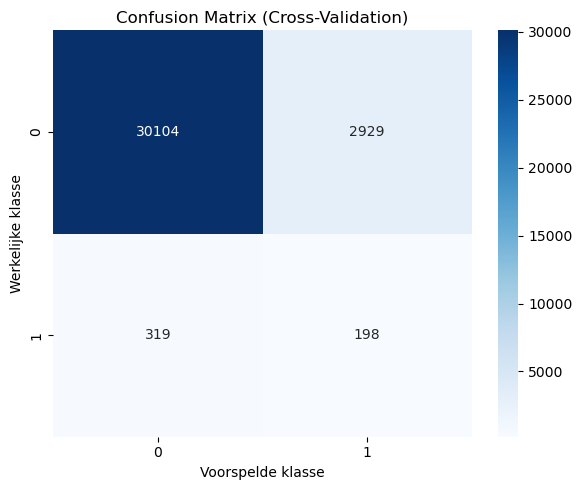

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
)

# 1. Dataset laden (vervang 'train' door jouw geladen DataFrame)
# train = pd.read_csv("data.csv")
X_train, y_train = train.drop(columns=["stroke"]), train["stroke"]

# 2. GridSearch instellen met F1-score als evaluatiemetriek
rf_model = RandomForestClassifier(random_state=42)
param_grid = {
    "n_estimators": [50, 100, 200],
    "max_depth": [None, 10, 20],
    "min_samples_split": [2, 5],
    "min_samples_leaf": [1, 2],
    "class_weight": [None, "balanced"],  # Helpt F1-score te verbeteren bij ongemiddelde klassen (zoals stroke)
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=rf_model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro",  # Optimaliseert specifiek op F1-score (macro)
    n_jobs=-1,
)

grid_search.fit(X_train, y_train)

# 3. Beste F1-score en parameters printen
print(f"Beste F1-score (macro) uit GridSearch: {grid_search.best_score_:.4f}")
print(f"Beste parameters: {grid_search.best_params_}\n")

# 4. Out-of-fold voorspellingen genereren op de trainingsset
best_rf = grid_search.best_estimator_
y_pred = cross_val_predict(best_rf, X_train, y_train, cv=cv)

# 5. Volledig overzicht van metrieken (Accuracy, Precision, Recall, F1-score)
print("=== Volledig Evaluatierapport (Cross-Validation) ===")
print(classification_report(y_train, y_pred, digits=4))

# 6. Confusion matrix berekenen en visualiseren
cm = confusion_matrix(y_train, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1],
    yticklabels=[0, 1],
)
plt.title("Confusion Matrix (Cross-Validation)")
plt.xlabel("Voorspelde klasse")
plt.ylabel("Werkelijke klasse")
plt.tight_layout()
plt.show()

##### Gradient Boosted Decision Trees

Gradient Boosted Decision Trees maakt gebruik van het principe van boosting. In plaats van onafhankelijke bomen te bouwen, worden bomen achter elkaar geplaatst om elkaar aan te vullen. Elke nieuwe boom wordt getraind op de fouten (de residuals of residuen) van de voorgaande bomen. Het uiteindelijke model combineert de voorspellingen van al deze bomen met een bepaalde leersnelheid (learning rate).

Omdat elke nieuwe boom afhankelijk is van de resultaten en fouten van de vorige boom, verloopt het trainingsproces strikt sequential (volgordelijk). Dit leidt tot een lange trainingstijd, omdat een volgend algoritme pas kan starten wanneer de voorgaande boom volledig is afgerond.

Beste F1-score (macro) uit GridSearch: 0.5070
Beste parameters: {'class_weight': 'balanced', 'learning_rate': 0.1, 'max_depth': None, 'max_iter': 100, 'min_samples_leaf': 50}

=== Volledig Evaluatierapport (Cross-Validation) ===
              precision    recall  f1-score   support

           0     0.9942    0.8298    0.9046     33033
           1     0.0595    0.6886    0.1096       517

    accuracy                         0.8276     33550
   macro avg     0.5269    0.7592    0.5071     33550
weighted avg     0.9798    0.8276    0.8923     33550



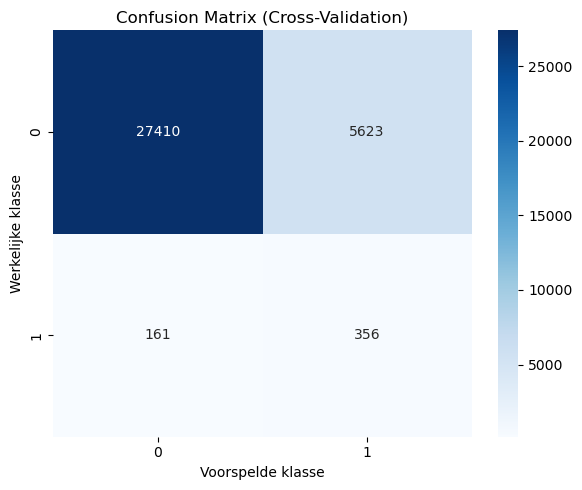

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
)

# 1. Dataset laden (vervang 'train' door jouw geladen DataFrame)
# train = pd.read_csv("data.csv")
X_train, y_train = train.drop(columns=["stroke"]), train["stroke"]

# 2. GridSearch instellen met F1-score als evaluatiemetriek voor Gradient Boosting
gb_model = HistGradientBoostingClassifier(random_state=42)
param_grid = {
    "learning_rate": [0.01, 0.05, 0.1],
    "max_iter": [100, 200],
    "max_depth": [3, 5, 10, None],
    "min_samples_leaf": [20, 50],
    "class_weight": [None, "balanced"],  # Optimaliseert F1-score bij scheve klasse-verdeling
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=gb_model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1_macro"  # Optimaliseert specifiek op F1-score (macro)
)

grid_search.fit(X_train, y_train)

# 3. Beste F1-score en parameters printen
print(f"Beste F1-score (macro) uit GridSearch: {grid_search.best_score_:.4f}")
print(f"Beste parameters: {grid_search.best_params_}\n")

# 4. Out-of-fold voorspellingen genereren op de trainingsset
best_gb = grid_search.best_estimator_
y_pred = cross_val_predict(best_gb, X_train, y_train, cv=cv)

# 5. Volledig overzicht van metrieken (Accuracy, Precision, Recall, F1-score)
print("=== Volledig Evaluatierapport (Cross-Validation) ===")
print(classification_report(y_train, y_pred, digits=4))

# 6. Confusion matrix berekenen en visualiseren
cm = confusion_matrix(y_train, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1],
    yticklabels=[0, 1],
)
plt.title("Confusion Matrix (Cross-Validation)")
plt.xlabel("Voorspelde klasse")
plt.ylabel("Werkelijke klasse")
plt.tight_layout()
plt.show()

#### XGBoost
XGBoost is een sterk geoptimaliseerde en geavanceerde variant van boosting (GBDT). Het volgt hetzelfde basisprincipe waarbij bomen opeenvolgend fouten van vorige bomen proberen te herstellen, maar voegt daar ingebouwde L1- en L2-regularisatie, automatische hantering van ontbrekende waarden en slimme sorteeralgoritmes aan toe.

Op modelniveau werkt XGBoost sequential doordat bomen opeenvolgend worden opgebouwd. Toch heeft XGBoost een relatief korte trainingstijd (zeker in vergelijking met standaard GBDT). Dit komt doordat het algoritme de berekeningen binnen de constructie van een enkele boom — zoals het zoeken naar de beste splitsingspunten over verschillende kenmerken — wel parallel kan uitvoeren over de CPU/GPU.

In [ ]:
#pip install xgboost

   ---------------------------------------- 0.0/48.9 MB ? eta -:--:--
   -- ------------------------------------- 3.4/48.9 MB 16.4 MB/s eta 0:00:03
   ------ --------------------------------- 7.6/48.9 MB 18.0 MB/s eta 0:00:03
   ---------- ----------------------------- 12.3/48.9 MB 19.4 MB/s eta 0:00:02
   ------------- -------------------------- 16.8/48.9 MB 19.9 MB/s eta 0:00:02
   ----------------- ---------------------- 21.5/48.9 MB 20.3 MB/s eta 0:00:02
   --------------------- ------------------ 26.2/48.9 MB 20.5 MB/s eta 0:00:02
   ------------------------- -------------- 30.7/48.9 MB 20.7 MB/s eta 0:00:01
   ---------------------------- ----------- 35.4/48.9 MB 20.7 MB/s eta 0:00:01
   -------------------------------- ------- 39.8/48.9 MB 20.8 MB/s eta 0:00:01
   ------------------------------------ --- 44.6/48.9 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 20.9 MB/s eta 0:00:01
   ---------------------------------------  48.8/48.9 MB 20.9 M

Beste F1-score (macro) uit GridSearch: 0.1163
Beste parameters: {'learning_rate': 0.01, 'max_depth': 10, 'n_estimators': 100, 'scale_pos_weight': 63.8936170212766, 'subsample': 0.8}

=== Volledig Evaluatierapport (Cross-Validation) ===
              precision    recall  f1-score   support

           0     0.9903    0.9059    0.9462     33033
           1     0.0672    0.4333    0.1164       517

    accuracy                         0.8987     33550
   macro avg     0.5288    0.6696    0.5313     33550
weighted avg     0.9761    0.8987    0.9335     33550



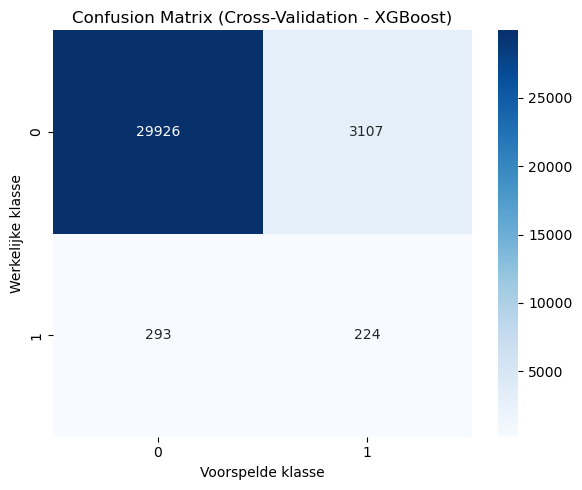

In [ ]:
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_predict,
)
from xgboost import XGBClassifier

# Voorkom de joblib/loky waarschuwing op Windows
os.environ["LOKY_MAX_CPU_COUNT"] = "4"

# 1. Dataset laden (vervang 'train' door jouw geladen DataFrame)
# train = pd.read_csv("data.csv")
X_train, y_train = train.drop(columns=["stroke"]), train["stroke"]

# 2. Klasse-imbalans verhouding berekenen voor XGBoost
# XGBoost gebruikt scale_pos_weight i.p.v. class_weight="balanced"
scale_pos_weight_value = (len(y_train) - sum(y_train)) / sum(y_train)

# 3. GridSearch instellen met F1-score als evaluatiemetriek
xgb_model = XGBClassifier(random_state=42, eval_metric="logloss")

param_grid = {
    "n_estimators": [100, 200],
    "max_depth": [3, 5, 10],
    "learning_rate": [0.01, 0.05, 0.1],
    "subsample": [0.8, 1.0],
    "scale_pos_weight": [1, scale_pos_weight_value],  # Optimaliseert F1-score bij ongemiddelde klassen
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

grid_search = GridSearchCV(
    estimator=xgb_model,
    param_grid=param_grid,
    cv=cv,
    scoring="f1",  # Optimaliseert specifiek op F1-score 

)

grid_search.fit(X_train, y_train)

# 4. Beste F1-score en parameters printen
print(f"Beste F1-score (macro) uit GridSearch: {grid_search.best_score_:.4f}")
print(f"Beste parameters: {grid_search.best_params_}\n")

# 5. Out-of-fold voorspellingen genereren op de trainingsset
best_xgb = grid_search.best_estimator_
y_pred = cross_val_predict(best_xgb, X_train, y_train, cv=cv)

# 6. Volledig overzicht van metrieken (Accuracy, Precision, Recall, F1-score)
print("=== Volledig Evaluatierapport (Cross-Validation) ===")
print(classification_report(y_train, y_pred, digits=4))

# 7. Confusion matrix berekenen en visualiseren
cm = confusion_matrix(y_train, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1],
    yticklabels=[0, 1],
)
plt.title("Confusion Matrix (Cross-Validation - XGBoost)")
plt.xlabel("Voorspelde klasse")
plt.ylabel("Werkelijke klasse")
plt.tight_layout()
plt.show()

Beste hyperparameters: {'svm__C': 0.5, 'svm__gamma': 0.05}
Beste gemiddelde F1-score (CV): 0.0893
=== Volledig Evaluatierapport ===
              precision    recall  f1-score   support

           0     0.5050    0.7595    0.6066      4241
           1     0.4925    0.2387    0.3216      4147

    accuracy                         0.5020      8388
   macro avg     0.4988    0.4991    0.4641      8388
weighted avg     0.4988    0.5020    0.4657      8388



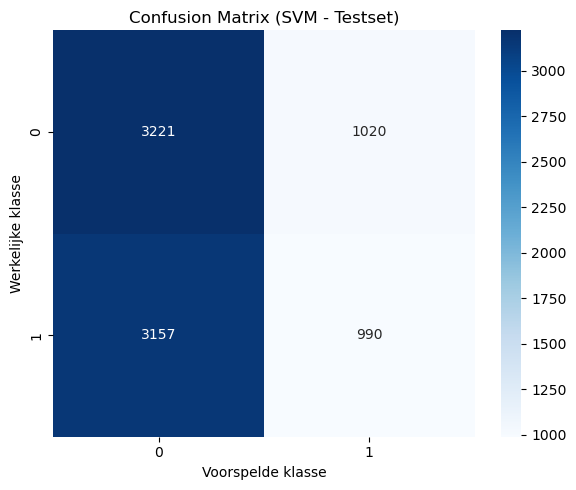

In [19]:
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

import pandas as pd
from sklearn.model_selection import GridSearchCV, RepeatedStratifiedKFold
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

# 1. Pipeline opzetten (voorkomt data leakage tijdens CV)
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('svm', SVC(kernel='rbf', class_weight='balanced', random_state=42))
])

# 2. Parametergrid definiëren
param_grid = {
    'svm__C': [0.1, 0.5, 1.0, 2.0, 5.0],
    'svm__gamma': ['scale', 'auto', 0.01, 0.05, 0.1]
}

# 3. Repeated Stratified K-Fold CV (robuustere evaluatie bij imbalanced data)
cv_strategy = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=42)

# 4. GridSearchCV met de pipeline
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring='f1',
    cv=cv_strategy,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print(f"Beste hyperparameters: {grid_search.best_params_}")
print(f"Beste gemiddelde F1-score (CV): {grid_search.best_score_:.4f}")

# 5. Voorspellen op de testset
best_model = grid_search.best_estimator_
y_pred = best_model.predict(X_test)

# 6. Volledig overzicht van metrieken (Accuracy, Precision, Recall, F1-score)
print("=== Volledig Evaluatierapport ===")
print(classification_report(y_test, y_pred, digits=4))

# 7. Confusion matrix berekenen en visualiseren
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[0, 1],
    yticklabels=[0, 1],
)
plt.title("Confusion Matrix (SVM - Testset)")
plt.xlabel("Voorspelde klasse")
plt.ylabel("Werkelijke klasse")
plt.tight_layout()
plt.show()

In [12]:
print("Aantal strokes (1) in de testset:", (y_test == 1).sum())
print("Aantal strokes (0) in de testset:", (y_test == 0).sum())

Aantal strokes (1) in de testset: stroke    4147
dtype: int64
Aantal strokes (0) in de testset: stroke    4241
dtype: int64
